<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec06_r2_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# R² (결정 계수) 실습

이 실습에서는 회귀 모델의 성능을 평가하는 R² (결정 계수)를 학습합니다:
1. 선형 회귀 모델 학습
2. R² Score 직접 구현
3. sklearn의 r2_score와 비교

**R² (Coefficient of Determination) 공식:**

$$R^2 = 1 - \frac{RSS}{TSS} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- **TSS (Total Sum of Squares)**: 총 변동량 = $\sum(y_i - \bar{y})^2$
- **RSS (Residual Sum of Squares)**: 잔차 제곱합 = $\sum(y_i - \hat{y}_i)^2$

**총점: 100점**

**학번:** 2023042028\
**이름:** 권택주

---
## Part 1: 데이터셋 준비 및 시각화 (20점)

선형 관계를 가진 데이터셋을 로드하고 시각화합니다.

---

### 문제 1-1. 데이터셋 시각화 [20점]

주어진 x, y 데이터를 산점도로 시각화합니다.

**예상 결과:** 양의 선형 관계를 보이는 산점도

데이터 개수: 10
x 범위: 1.78 ~ 10.92
y 범위: 1.06 ~ 5.37


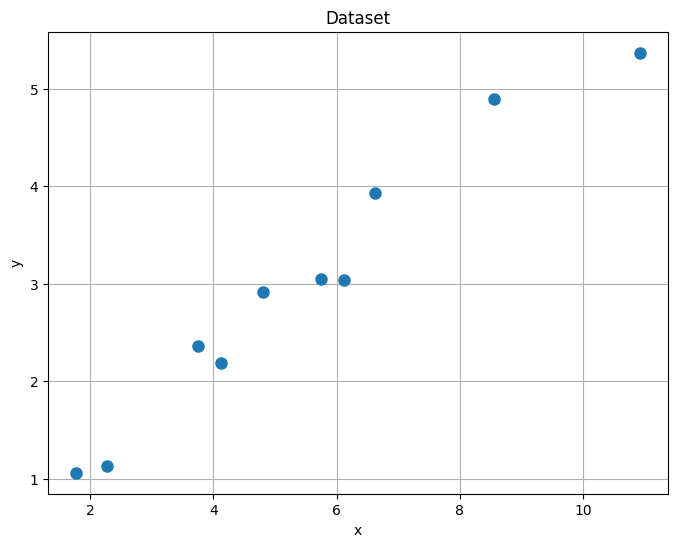

In [1]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(44)

# Dataset
x = np.array([1.78, 6.12, 6.63, 4.13, 8.55, 10.92, 4.81, 3.75, 2.28, 5.74]).reshape(-1, 1)
y = np.array([1.06, 3.04, 3.93, 2.19, 4.89, 5.37, 2.91, 2.36, 1.13, 3.05])

print(f"데이터 개수: {len(x)}")
print(f"x 범위: {x.min():.2f} ~ {x.max():.2f}")
print(f"y 범위: {y.min():.2f} ~ {y.max():.2f}")

plt.figure(figsize=(8, 6))
plt.plot(x, y, 'o', markersize=8)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dataset')
plt.grid(True)
plt.show()

---
## Part 2: 선형 회귀 모델 학습 (20점)

sklearn의 LinearRegression을 사용하여 모델을 학습합니다.

---

### 문제 2-1. 선형 회귀 학습 및 시각화 [20점]

LinearRegression 모델을 학습하고 회귀선을 시각화합니다.

**예상 결과:** 데이터 포인트와 회귀선이 함께 표시된 그래프

기울기 (slope): 0.5031
절편 (intercept): 0.2403


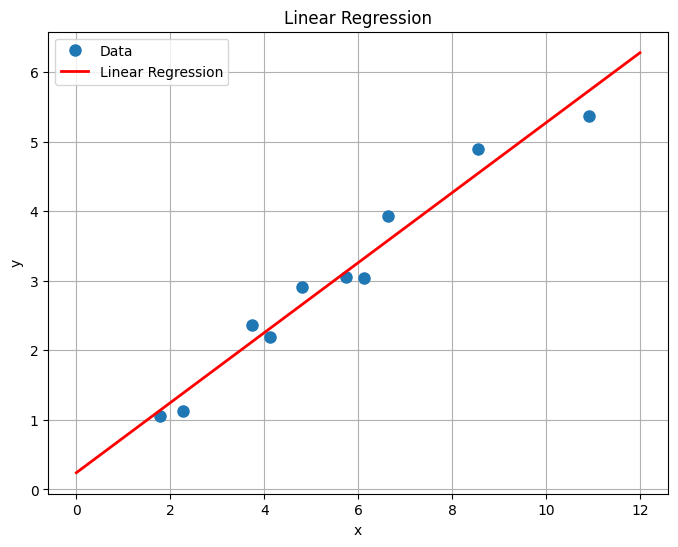

In [2]:
#@title { vertical-output: true}
from sklearn.linear_model import LinearRegression

# 모델 학습
model_linear = LinearRegression()
model_linear.fit(x, y)

print(f"기울기 (slope): {model_linear.coef_[0]:.4f}")
print(f"절편 (intercept): {model_linear.intercept_:.4f}")

# 예측선 생성
x_test = np.linspace(0, 12, 100).reshape(100, 1)
y_test = model_linear.predict(x_test)

# 시각화
plt.figure(figsize=(8, 6))
plt.plot(x, y, 'o', markersize=8, label='Data')
plt.plot(x_test, y_test, 'r-', linewidth=2, label='Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

---
## Part 3: R² Score 직접 구현 (60점)

R² Score를 직접 구현하고 sklearn의 결과와 비교합니다.

**R² 해석:**
- R² = 1: 완벽한 예측 (모든 데이터가 회귀선 위에 있음)
- R² = 0: 모델이 평균값만큼만 예측
- R² < 0: 평균값보다 못한 예측

---

### 문제 3-1. R² Score 함수 구현 [60점]

R² Score를 계산하는 함수를 직접 구현합니다.

**문제:** `my_r2_score` 함수를 완성하세요.

**구현 순서:**
1. y의 평균(y_mean) 계산
2. TSS (Total Sum of Squares) 계산: $\sum(y_i - \bar{y})^2$
3. RSS (Residual Sum of Squares) 계산: $\sum(y_i - \hat{y}_i)^2$
4. R² 계산: $1 - \frac{RSS}{TSS}$

**힌트:**
```python
y_mean = np.mean(y_true)
tss = np.sum((y_true - y_mean) ** 2)
rss = np.sum((y_true - y_pred) ** 2)
r2 = 1 - (rss / tss)
```

**예상 결과:**
```
R2 (직접 구현): 0.9637
R2 (sklearn): 0.9637
```

In [3]:
#@title { vertical-output: true}
from sklearn.metrics import r2_score

def my_r2_score(y_true, y_pred):
    """
    R² Score (Coefficient of Determination) 계산

    Parameters:
    - y_true: 실제 값
    - y_pred: 예측 값

    Returns:
    - r2: R² Score
    """
    # IMPLEMENT HERE: y의 평균 계산
    y_mean = np.mean(y_true)

    # IMPLEMENT HERE: TSS (Total Sum of Squares) 계산
    tss = np.sum((y_true - y_mean) ** 2)

    # IMPLEMENT HERE: RSS (Residual Sum of Squares) 계산
    rss = np.sum((y_true - y_pred) ** 2)

    # IMPLEMENT HERE: R² 계산
    r2 = 1 - (rss / tss)

    return r2

# 예측값 계산
y_hat = model_linear.predict(x)

# 직접 구현한 R² 계산
r2_custom = my_r2_score(y.reshape(-1, 1), y_hat.reshape(-1, 1))
print(f'R2 (직접 구현): {r2_custom:.10f}')

# sklearn의 R² 계산
r2_sklearn = r2_score(y.reshape(-1, 1), y_hat.reshape(-1, 1))
print(f'R2 (sklearn): {r2_sklearn:.10f}')

# 결과 비교
print(f'\n두 값의 차이: {abs(r2_custom - r2_sklearn):.15f}')

R2 (직접 구현): 0.9636537723
R2 (sklearn): 0.9636537723

두 값의 차이: 0.000000000000000


### R² Score 해석

R² ≈ 0.96 의미:
- 전체 변동(TSS)의 약 96%를 모델이 설명할 수 있음
- 나머지 4%는 모델이 설명하지 못하는 잔차(RSS)

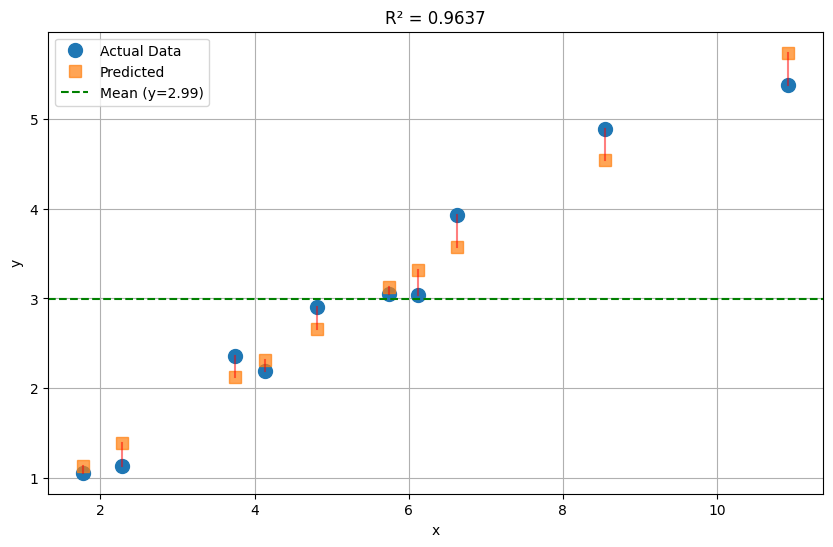

In [4]:
#@title { vertical-output: true}
# R² 시각적 이해
y_mean = np.mean(y)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o', markersize=10, label='Actual Data')
plt.plot(x, y_hat, 's', markersize=8, alpha=0.7, label='Predicted')
plt.axhline(y=y_mean, color='g', linestyle='--', label=f'Mean (y={y_mean:.2f})')

# 잔차 표시
for i in range(len(x)):
    plt.plot([x[i], x[i]], [y[i], y_hat[i]], 'r-', alpha=0.5)

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'R² = {r2_sklearn:.4f}')
plt.legend()
plt.grid(True)
plt.show()

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `r2_학번_이름.ipynb`, `r2_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---